In [6]:
group1 = df[df["recruitment_status"].isin([
    "COMPLETED", "TERMINATED", "WITHDRAWN"
])]

group2 = df[df["recruitment_status"].isin([
    "RECRUITING", "ACTIVE_NOT_RECRUITING", 
    "NOT_YET_RECRUITING", "ENROLLING_BY_INVITATION"
])]

group3 = df[df["recruitment_status"].isin([
    "UNKNOWN", "SUSPENDED"
])]

print(f"Group 1 — Definitive outcomes : {len(group1)}")
print(f"Group 2 — Ongoing/censored    : {len(group2)}")
print(f"Group 3 — Ambiguous           : {len(group3)}")

Group 1 — Definitive outcomes : 616
Group 2 — Ongoing/censored    : 259
Group 3 — Ambiguous           : 125


In [9]:
# ─────────────────────────────────────────────────────────
# PART 2 — ANALYSIS
# ─────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────
# SECTION 1 — SUCCESS DEFINITION
# ─────────────────────────────────────────────────────────

def assign_outcome(row):
    """
    Assign outcome label to each trial.
    
    Success: COMPLETED + phase >= 2 + enrollment > 0 
             + has_drug + standard trial
    Failure: TERMINATED + standard trial
    Excluded: everything else
    """
    
    # Exclude non-standard trials (missing phase)
    if row["trial_type"] == "non_standard":
        return "excluded_non_standard"
    
    # Exclude trials with no drug
    if not row["has_drug"]:
        return "excluded_no_drug"
    
    status = row["recruitment_status"]
    
    # Ongoing — right censored
    if status in ("RECRUITING", "ACTIVE_NOT_RECRUITING",
                  "NOT_YET_RECRUITING", "ENROLLING_BY_INVITATION"):
        return "ongoing"
    
    # Ambiguous
    if status in ("UNKNOWN", "SUSPENDED"):
        return "ambiguous"
    
    # Withdrawn — never started
    if status == "WITHDRAWN":
        return "withdrawn"
    
    # Terminated — active failure
    if status == "TERMINATED":
        return "failure"
    
    # Completed — check additional conditions
    if status == "COMPLETED":
        if row["phase_numeric"] >= 2 and row["enrollment"] > 0:
            return "success"
        elif row["phase_numeric"] < 2:
            return "excluded_phase1_only"
        elif row["enrollment"] == 0:
            return "excluded_zero_enrollment"
    
    return "excluded_other"

df["outcome"] = df.apply(assign_outcome, axis=1)

print("OUTCOME DISTRIBUTION")
print("=" * 50)
print(df["outcome"].value_counts().to_string())

print(f"\nTrials used for success rate calculation:")
analytical = df[df["outcome"].isin(["success", "failure"])]
print(f"  Success : {(analytical['outcome'] == 'success').sum()}")
print(f"  Failure : {(analytical['outcome'] == 'failure').sum()}")
print(f"  Total   : {len(analytical)}")

OUTCOME DISTRIBUTION
outcome
success                  271
ongoing                  242
excluded_phase1_only     138
failure                  118
ambiguous                114
excluded_non_standard     40
withdrawn                 36
excluded_no_drug          24
excluded_other            17

Trials used for success rate calculation:
  Success : 271
  Failure : 118
  Total   : 389


In [10]:
# ─────────────────────────────────────────────────────────
# SECTION 2 — STRATIFIED SUCCESS RATES
# ─────────────────────────────────────────────────────────

# Work only with trials that have definitive outcomes
df_analysis = df[df["outcome"].isin(["success", "failure"])].copy()
df_analysis["success_binary"] = (df_analysis["outcome"] == "success").astype(int)

print(f"Working dataset: {len(df_analysis)} trials")
print(f"Overall success rate: {df_analysis['success_binary'].mean()*100:.1f}%")

def success_rate_table(data, group_col, label, min_n=5):
    """
    Compute success rate by a grouping column.
    Suppress strata with fewer than min_n trials.
    """
    grouped = data.groupby(group_col)["success_binary"].agg(
        trials="count",
        successes="sum"
    ).reset_index()
    
    grouped["success_rate_%"] = (
        grouped["successes"] / grouped["trials"] * 100
    ).round(1)
    
    # Suppress small strata
    grouped = grouped[grouped["trials"] >= min_n]
    grouped = grouped.sort_values("success_rate_%", ascending=False)
    
    print(f"\n{label}")
    print("=" * 50)
    print(grouped.to_string(index=False))
    
    return grouped

Working dataset: 389 trials
Overall success rate: 69.7%


In [11]:
# DIMENSION 1 — BY PHASE
sr_phase = success_rate_table(
    df_analysis, 
    "phase", 
    "SUCCESS RATE BY PHASE"
)


SUCCESS RATE BY PHASE
        phase  trials  successes  success_rate_%
       PHASE4      14         13            92.9
       PHASE3      66         52            78.8
PHASE2/PHASE3       9          7            77.8
       PHASE2     200        150            75.0
PHASE1/PHASE2      68         49            72.1
       PHASE1      31          0             0.0


In [12]:
# DIMENSION 2 — BY PRIMARY TECHNOLOGY
sr_tech = success_rate_table(
    df_analysis,
    "primary_technology",
    "SUCCESS RATE BY TECHNOLOGY TYPE"
)


SUCCESS RATE BY TECHNOLOGY TYPE
        primary_technology  trials  successes  success_rate_%
     Other Protein Therapy      15         13            86.7
                  Antibody      51         38            74.5
            Small Molecule     243        171            70.4
                   Unknown      40         27            67.5
Engineered Protein Therapy       9          6            66.7


In [13]:
# DIMENSION 3 — BY PRIMARY TARGET
sr_target = success_rate_table(
    df_analysis,
    "primary_target",
    "SUCCESS RATE BY TARGET CLASS (min 5 trials)",
    min_n=5
)


SUCCESS RATE BY TARGET CLASS (min 5 trials)
primary_target  trials  successes  success_rate_%
  EPO receptor       6          6           100.0
          TYMS      14         12            85.7
          CD20       6          5            83.3
          EGFR      17         14            82.4
          PDL1       5          4            80.0
            GR      10          8            80.0
           DNA      38         27            71.1
       Unknown      55         39            70.9
         TUBB1      23         16            69.6
          PD-1      11          7            63.6
          CRAF       5          3            60.0
            AR       5          3            60.0
      BCR-ABL1       5          3            60.0
         PI3Kα       5          3            60.0
        VEGF-A       7          3            42.9
    Proteasome       8          3            37.5


In [14]:
# DIMENSION 4 — INDICATION x PHASE
# Use broad_category and phase_numeric
# Only Phase 2 and Phase 3 — enough trials for meaningful analysis

df_indphase = df_analysis[
    df_analysis["phase"].isin(["PHASE2", "PHASE3"])
].copy()

cross = df_indphase.groupby(
    ["broad_category", "phase"]
)["success_binary"].agg(
    trials="count",
    successes="sum"
).reset_index()

cross["success_rate_%"] = (
    cross["successes"] / cross["trials"] * 100
).round(1)

# Suppress small strata
cross = cross[cross["trials"] >= 5]
cross = cross.sort_values(
    ["broad_category", "phase"]
)

print("\nSUCCESS RATE BY INDICATION x PHASE")
print("=" * 50)
print(cross.to_string(index=False))


SUCCESS RATE BY INDICATION x PHASE
    broad_category  phase  trials  successes  success_rate_%
      Brain Cancer PHASE2       9          8            88.9
     Breast Cancer PHASE2      24         21            87.5
 Colorectal Cancer PHASE2       5          5           100.0
 Esophageal Cancer PHASE2       5          4            80.0
Gynecologic Cancer PHASE2       8          6            75.0
     Kidney Cancer PHASE2       7          5            71.4
          Leukemia PHASE2      22         14            63.6
       Lung Cancer PHASE2      16          9            56.2
       Lung Cancer PHASE3       5          4            80.0
          Lymphoma PHASE2      12         12           100.0
  Multiple Myeloma PHASE2      10          5            50.0
        Non-Cancer PHASE3       8          6            75.0
      Other Cancer PHASE2      17         14            82.4
      Other Cancer PHASE3      12         10            83.3
 Pancreatic Cancer PHASE2       5          5     

In [15]:
# ─────────────────────────────────────────────────────────
# SECTION 3 — VISUALISATIONS
# ─────────────────────────────────────────────────────────

sns.set_theme(style="whitegrid", palette="muted")

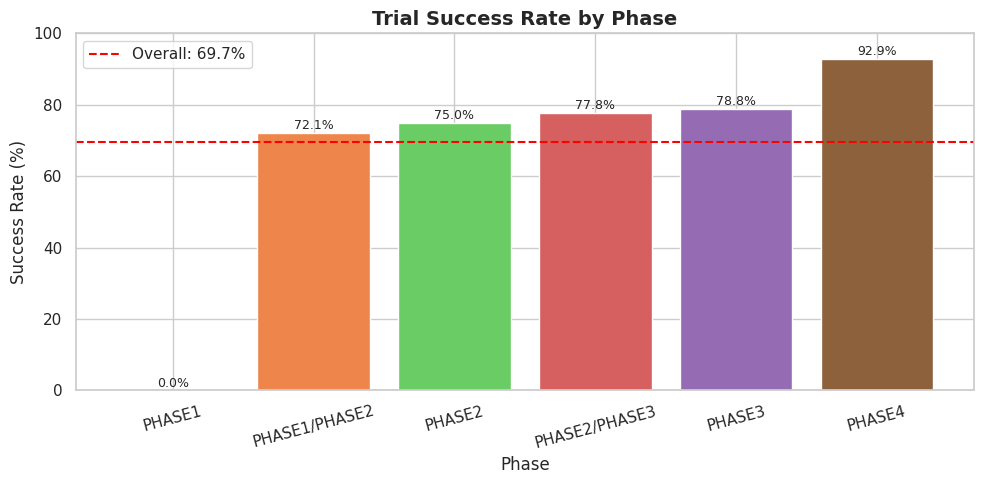

In [17]:
# 3A — SUCCESS RATE BY PHASE
fig, ax = plt.subplots(figsize=(10, 5))

# Sort by phase order not success rate
phase_order = ["EARLY_PHASE1", "PHASE1", "PHASE1/PHASE2", 
               "PHASE2", "PHASE2/PHASE3", "PHASE3", "PHASE4"]
sr_phase_sorted = sr_phase.set_index("phase").reindex(
    [p for p in phase_order if p in sr_phase["phase"].values]
).reset_index()

bars = ax.bar(
    sr_phase_sorted["phase"],
    sr_phase_sorted["success_rate_%"],
    color=sns.color_palette("muted")
)

ax.set_title("Trial Success Rate by Phase", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Phase")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 100)
ax.axhline(y=df_analysis["success_binary"].mean()*100, 
           color="red", linestyle="--", 
           label=f"Overall: {df_analysis['success_binary'].mean()*100:.1f}%")
ax.legend()

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center", fontsize=9)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("success_by_phase.png", dpi=150)
plt.show()

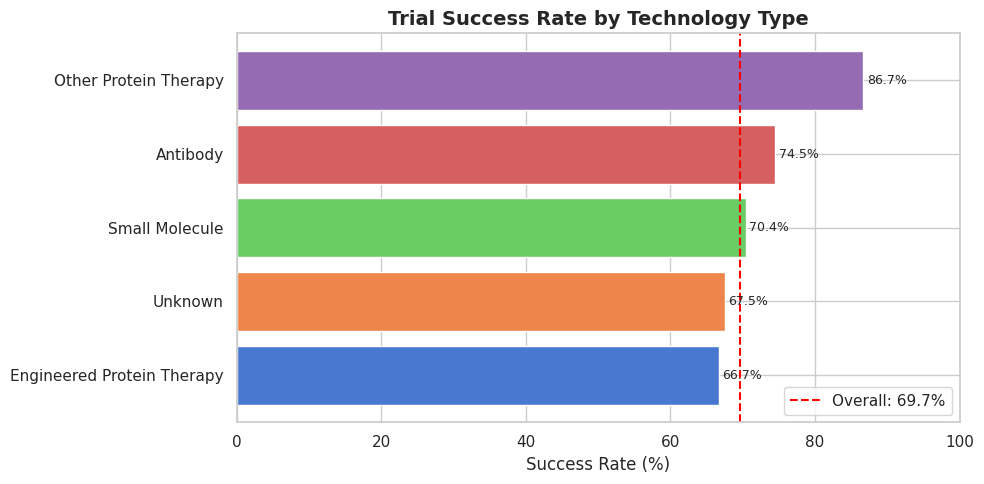

In [18]:
# 3B — SUCCESS RATE BY TECHNOLOGY
fig, ax = plt.subplots(figsize=(10, 5))

sr_tech_plot = sr_tech.sort_values("success_rate_%", ascending=True)

bars = ax.barh(
    sr_tech_plot["primary_technology"],
    sr_tech_plot["success_rate_%"],
    color=sns.color_palette("muted")
)

ax.set_title("Trial Success Rate by Technology Type",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.set_xlim(0, 100)
ax.axvline(x=df_analysis["success_binary"].mean()*100,
           color="red", linestyle="--",
           label=f"Overall: {df_analysis['success_binary'].mean()*100:.1f}%")
ax.legend()

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("success_by_technology.png", dpi=150)
plt.show()

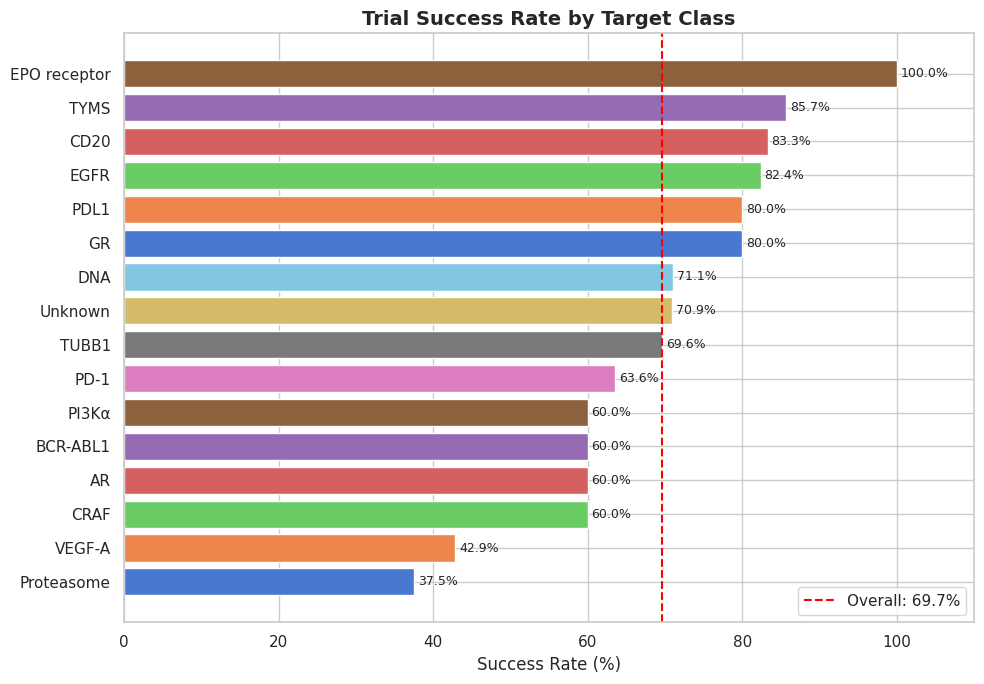

In [19]:
# 3C — SUCCESS RATE BY TARGET CLASS
fig, ax = plt.subplots(figsize=(10, 7))

sr_target_plot = sr_target.sort_values("success_rate_%", ascending=True)

bars = ax.barh(
    sr_target_plot["primary_target"],
    sr_target_plot["success_rate_%"],
    color=sns.color_palette("muted")
)

ax.set_title("Trial Success Rate by Target Class",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.set_xlim(0, 110)
ax.axvline(x=df_analysis["success_binary"].mean()*100,
           color="red", linestyle="--",
           label=f"Overall: {df_analysis['success_binary'].mean()*100:.1f}%")
ax.legend()

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("success_by_target.png", dpi=150)
plt.show()

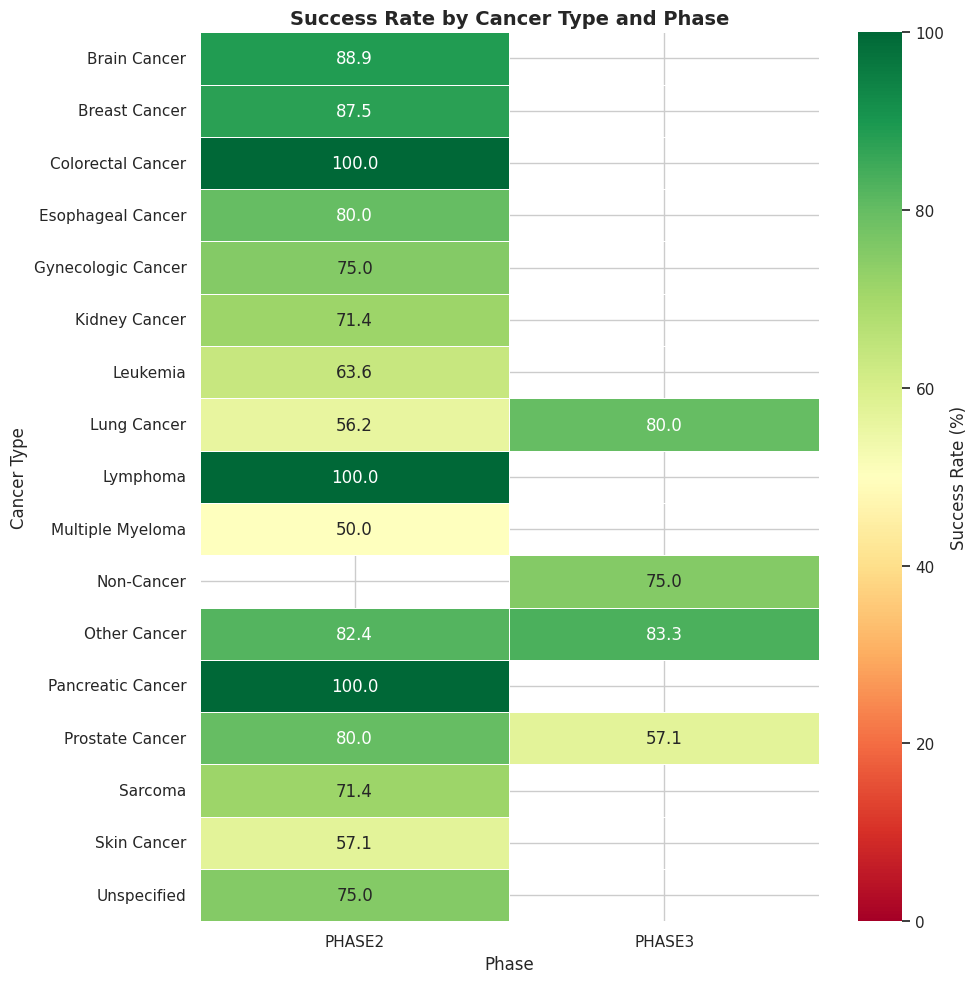

In [21]:
# 3D — INDICATION x PHASE HEATMAP
pivot = cross.pivot(
    index="broad_category",
    columns="phase",
    values="success_rate_%"
)

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Success Rate (%)"}
)

ax.set_title("Success Rate by Cancer Type and Phase",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Phase")
ax.set_ylabel("Cancer Type")

plt.tight_layout()
plt.savefig("success_heatmap.png", dpi=150)
plt.show()

In [22]:
# ─────────────────────────────────────────────────────────
# SECTION 4 — RANDOM FOREST FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Prepare features
features = [
    "phase_numeric",
    "enrollment",
    "trial_duration_days",
    "primary_technology",
    "broad_category",
    "primary_target",
    "start_year"
]

# Work with analytical dataset only
df_ml = df_analysis[features + ["success_binary"]].copy()

# Drop rows with missing values
df_ml = df_ml.dropna()

print(f"ML dataset: {len(df_ml)} trials after dropping nulls")

# Encode categorical columns
le = LabelEncoder()
cat_cols = ["primary_technology", "broad_category", "primary_target"]

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Train Random Forest
X = df_ml[features]
y = df_ml["success_binary"]

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X, y)

# Cross validation score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print(f"\nCross-validated AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

ML dataset: 375 trials after dropping nulls

Cross-validated AUC: 0.782 (+/- 0.062)


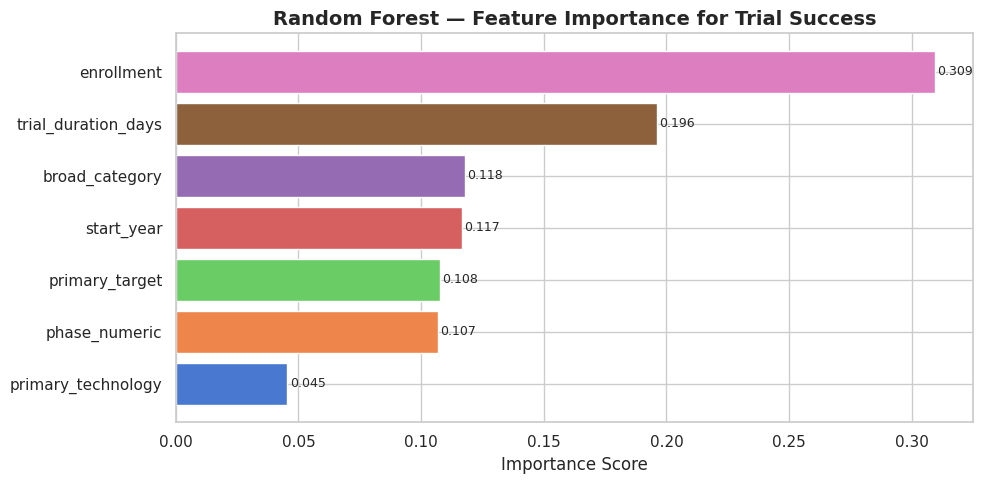


Feature Importance Ranking:
            feature  importance
         enrollment         0.3
trial_duration_days         0.2
     broad_category         0.1
         start_year         0.1
     primary_target         0.1
      phase_numeric         0.1
 primary_technology         0.0


In [23]:
# Feature importance
importance_df = pd.DataFrame({
    "feature"   : features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    importance_df["feature"],
    importance_df["importance"],
    color=sns.color_palette("muted")
)

ax.set_title("Random Forest — Feature Importance for Trial Success",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")

for bar in bars:
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nFeature Importance Ranking:")
print(importance_df.sort_values("importance", ascending=False).to_string(index=False))

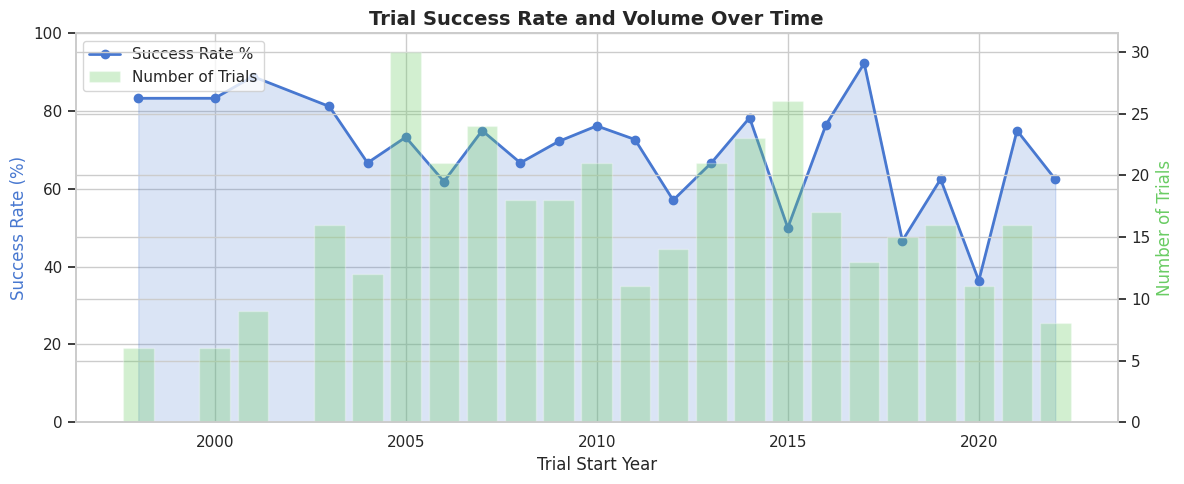

SUCCESS RATE BY DECADE
 decade  trials  successes  success_rate_%
   1990      17         14            82.4
   2000     157        115            73.2
   2010     177        119            67.2
   2020      37         23            62.2


In [25]:
# ─────────────────────────────────────────────────────────
#SUCCESS TREND OVER TIME
# ─────────────────────────────────────────────────────────

# Group by start year and calculate success rate
df_analysis["start_year"] = pd.to_numeric(df_analysis["start_year"], errors="coerce")

yearly = df_analysis.groupby("start_year")["success_binary"].agg(
    trials="count",
    successes="sum"
).reset_index()

yearly["success_rate_%"] = (yearly["successes"] / yearly["trials"] * 100).round(1)

# Only keep years with at least 5 trials
yearly = yearly[yearly["trials"] >= 5]

fig, ax1 = plt.subplots(figsize=(12, 5))

# Success rate line
ax1.plot(yearly["start_year"], yearly["success_rate_%"],
         marker="o", linewidth=2,
         color=sns.color_palette("muted")[0],
         label="Success Rate %")
ax1.fill_between(yearly["start_year"], yearly["success_rate_%"],
                 alpha=0.2, color=sns.color_palette("muted")[0])
ax1.set_xlabel("Trial Start Year")
ax1.set_ylabel("Success Rate (%)", color=sns.color_palette("muted")[0])
ax1.set_ylim(0, 100)

# Trial count bars on secondary axis
ax2 = ax1.twinx()
ax2.bar(yearly["start_year"], yearly["trials"],
        alpha=0.3, color=sns.color_palette("muted")[2],
        label="Number of Trials")
ax2.set_ylabel("Number of Trials", color=sns.color_palette("muted")[2])

ax1.set_title("Trial Success Rate and Volume Over Time",
              fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("success_over_time.png", dpi=150)
plt.show()

print("SUCCESS RATE BY DECADE")
print("=" * 40)
df_analysis["decade"] = (df_analysis["start_year"] // 10 * 10).astype("Int64")
decade = df_analysis.groupby("decade")["success_binary"].agg(
    trials="count", successes="sum"
).reset_index()
decade["success_rate_%"] = (decade["successes"] / decade["trials"] * 100).round(1)
print(decade.to_string(index=False))

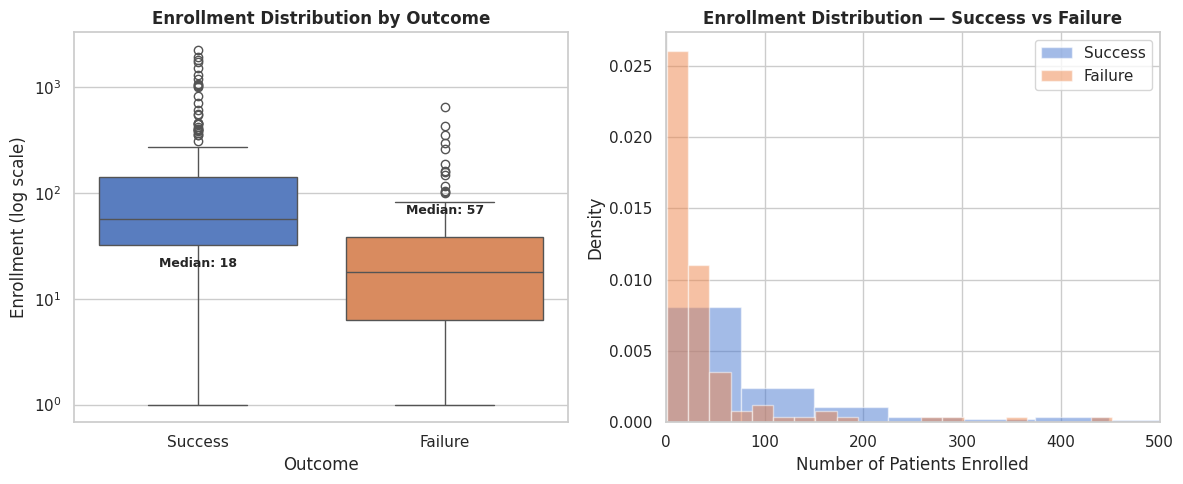

MEDIAN ENROLLMENT BY OUTCOME
               count  mean   std  min  25%  50%   75%    max
outcome_label                                               
Failure        118.0  43.7  87.0  1.0  6.2 18.0  38.0  645.0
Success        271.0 154.2 302.1  1.0 32.0 57.0 140.0 2239.0


In [26]:
# ─────────────────────────────────────────────────────────
# ENROLLMENT DISTRIBUTION BY OUTCOME
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
df_analysis_enroll = df_analysis[df_analysis["enrollment"] > 0].copy()
df_analysis_enroll["outcome_label"] = df_analysis_enroll["outcome"].map(
    {"success": "Success", "failure": "Failure"}
)

sns.boxplot(
    data=df_analysis_enroll,
    x="outcome_label",
    y="enrollment",
    palette="muted",
    ax=axes[0]
)
axes[0].set_title("Enrollment Distribution by Outcome",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Number of Patients Enrolled")
axes[0].set_yscale("log")
axes[0].set_ylabel("Enrollment (log scale)")

# Median enrollment by outcome
medians = df_analysis_enroll.groupby("outcome_label")["enrollment"].median()
for i, (label, median) in enumerate(medians.items()):
    axes[0].text(i, median * 1.1, f"Median: {median:.0f}",
                 ha="center", fontsize=9, fontweight="bold")

# KDE plot
for outcome, color in zip(["Success", "Failure"],
                           sns.color_palette("muted")):
    subset = df_analysis_enroll[
        df_analysis_enroll["outcome_label"] == outcome
    ]["enrollment"]
    axes[1].hist(subset, bins=30, alpha=0.5,
                 label=outcome, color=color, density=True)

axes[1].set_title("Enrollment Distribution — Success vs Failure",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Patients Enrolled")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig("enrollment_by_outcome.png", dpi=150)
plt.show()

print("MEDIAN ENROLLMENT BY OUTCOME")
print("=" * 40)
print(df_analysis_enroll.groupby("outcome_label")["enrollment"].describe().round(1).to_string())

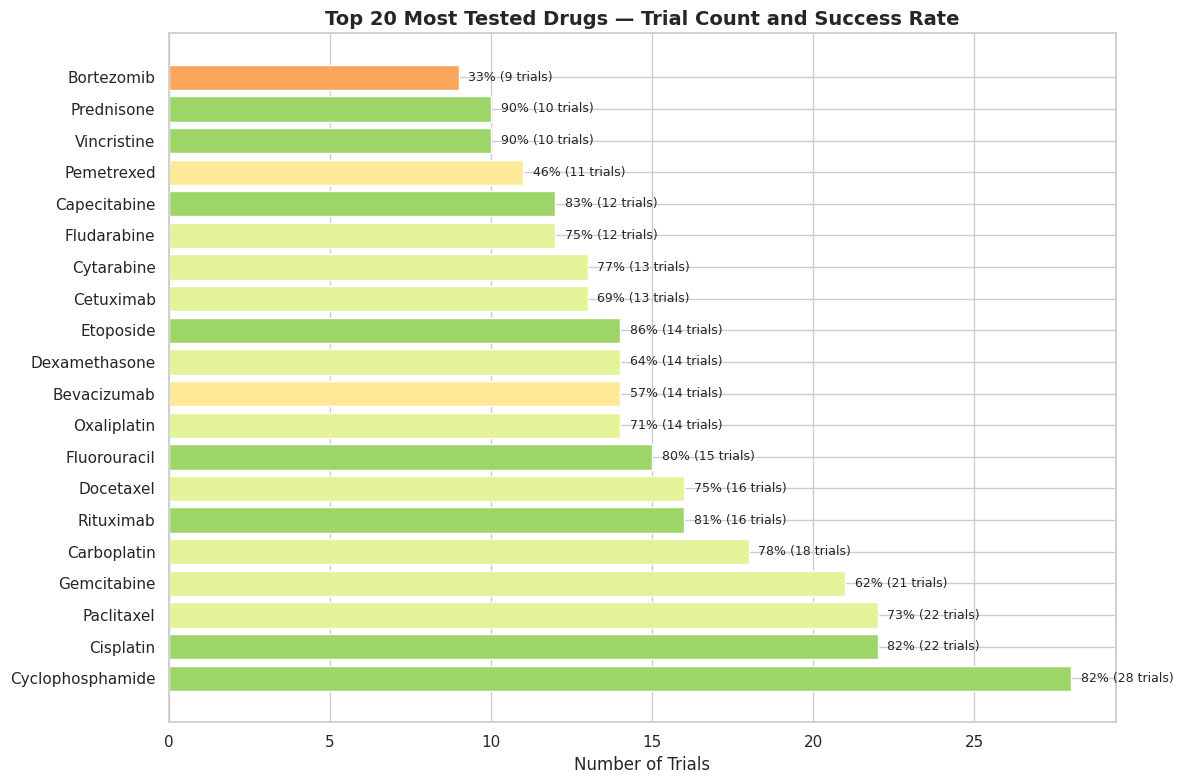


TOP 20 MOST TESTED DRUGS
interventions_drugs_clean  trials  successes  success_rate_%
         Cyclophosphamide      28         23            82.1
                Cisplatin      22         18            81.8
               Paclitaxel      22         16            72.7
              Gemcitabine      21         13            61.9
              Carboplatin      18         14            77.8
                Rituximab      16         13            81.2
                Docetaxel      16         12            75.0
             Fluorouracil      15         12            80.0
              Oxaliplatin      14         10            71.4
              Bevacizumab      14          8            57.1
            Dexamethasone      14          9            64.3
                Etoposide      14         12            85.7
                Cetuximab      13          9            69.2
               Cytarabine      13         10            76.9
              Fludarabine      12          9            75.

In [28]:
# ─────────────────────────────────────────────────────────
# MOST TESTED DRUGS AND SUCCESS RATES
# ─────────────────────────────────────────────────────────

# Parse drug lists — already parsed but stored as string in csv
import ast

def parse_list_col(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except:
        return []

df_analysis["interventions_drugs_clean"] = df_analysis[
    "interventions_drugs_clean"
].apply(parse_list_col)

# Explode drugs — one row per drug per trial
df_drugs_exploded = df_analysis.explode("interventions_drugs_clean")
df_drugs_exploded = df_drugs_exploded[
    df_drugs_exploded["interventions_drugs_clean"].notna()
]
df_drugs_exploded = df_drugs_exploded[
    df_drugs_exploded["interventions_drugs_clean"] != ""
]

# Exclude non-drugs
NON_DRUGS = {
    "Placebo", "Radiation Therapy", "Surgery",
    "Surgical Procedure", "Biospecimen Collection",
    "Questionnaire Administration", "Computed Tomography",
    "Magnetic Resonance Imaging", "Chemotherapy (unspecified)",
    "Immunotherapy (unspecified)", "Laboratory Biomarker Analysis"
}

df_drugs_exploded = df_drugs_exploded[
    ~df_drugs_exploded["interventions_drugs_clean"].isin(NON_DRUGS)
]

# Calculate success rate per drug
drug_success = df_drugs_exploded.groupby(
    "interventions_drugs_clean"
)["success_binary"].agg(
    trials="count",
    successes="sum"
).reset_index()

drug_success["success_rate_%"] = (
    drug_success["successes"] / drug_success["trials"] * 100
).round(1)

# Top 20 most tested drugs
top_drugs = drug_success[drug_success["trials"] >= 5].sort_values(
    "trials", ascending=False
).head(20)

fig, ax = plt.subplots(figsize=(12, 8))

colors = [
    sns.color_palette("RdYlGn")[
        int(rate / 100 * (len(sns.color_palette("RdYlGn")) - 1))
    ]
    for rate in top_drugs["success_rate_%"]
]

bars = ax.barh(
    top_drugs["interventions_drugs_clean"],
    top_drugs["trials"],
    color=colors
)

ax.set_title("Top 20 Most Tested Drugs — Trial Count and Success Rate",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Trials")

for bar, (_, row) in zip(bars, top_drugs.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{row['success_rate_%']:.0f}% ({int(row['trials'])} trials)",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("top_drugs_success.png", dpi=150)
plt.show()

print("\nTOP 20 MOST TESTED DRUGS")
print("=" * 50)
print(top_drugs[["interventions_drugs_clean", "trials",
                  "successes", "success_rate_%"]].to_string(index=False))

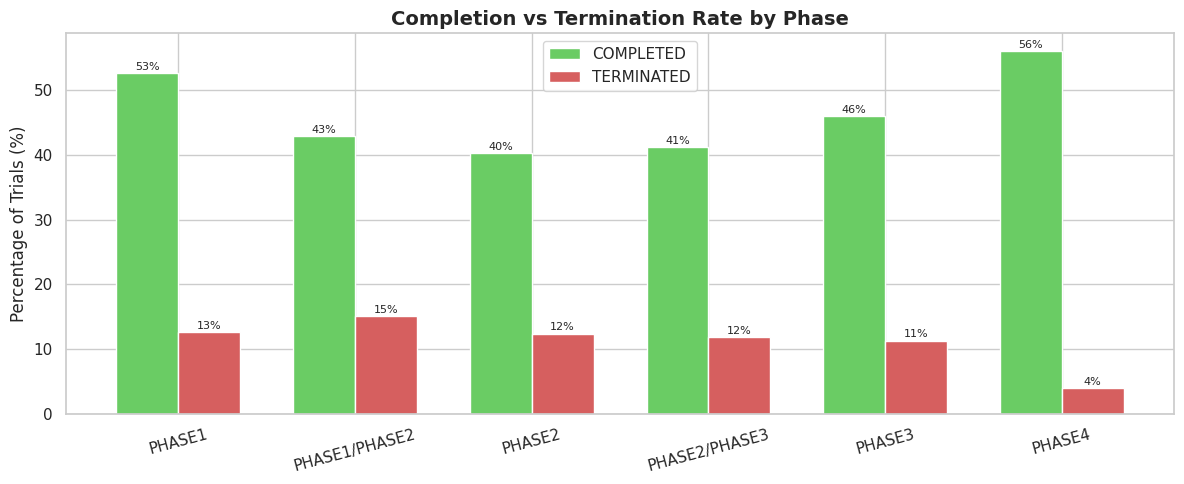


COMPLETION VS TERMINATION RATE BY PHASE
status         COMPLETED  TERMINATED
phase                               
PHASE1              52.6        12.6
PHASE1/PHASE2       42.9        15.1
PHASE2              40.3        12.4
PHASE2/PHASE3       41.2        11.8
PHASE3              46.0        11.3
PHASE4              56.0         4.0


In [29]:
# ─────────────────────────────────────────────────────────
#  PHASE TRANSITION ANALYSIS
# ─────────────────────────────────────────────────────────

# Compare completion rates across phase groups
# PHASE1/PHASE2 combo vs pure PHASE2 vs pure PHASE3

phase_groups = ["PHASE1", "PHASE1/PHASE2", "PHASE2", 
                "PHASE2/PHASE3", "PHASE3", "PHASE4"]

phase_transition = df[
    df["phase"].isin(phase_groups)
].groupby("phase")["recruitment_status"].value_counts(
    normalize=True
).mul(100).round(1).reset_index()
phase_transition.columns = ["phase", "status", "percentage"]

# Focus on COMPLETED vs TERMINATED rates
ct = phase_transition[
    phase_transition["status"].isin(["COMPLETED", "TERMINATED"])
]

pivot_ct = ct.pivot(
    index="phase", columns="status", values="percentage"
).fillna(0).reindex(phase_groups)

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(pivot_ct))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               pivot_ct["COMPLETED"],
               width, label="COMPLETED",
               color=sns.color_palette("muted")[2])

bars2 = ax.bar([i + width/2 for i in x],
               pivot_ct.get("TERMINATED", [0]*len(pivot_ct)),
               width, label="TERMINATED",
               color=sns.color_palette("muted")[3])

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_ct.index, rotation=15)
ax.set_title("Completion vs Termination Rate by Phase",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage of Trials (%)")
ax.legend()

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.0f}%",
                ha="center", fontsize=8)

for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.0f}%",
                ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("phase_transition.png", dpi=150)
plt.show()

print("\nCOMPLETION VS TERMINATION RATE BY PHASE")
print("=" * 50)
print(pivot_ct.to_string())

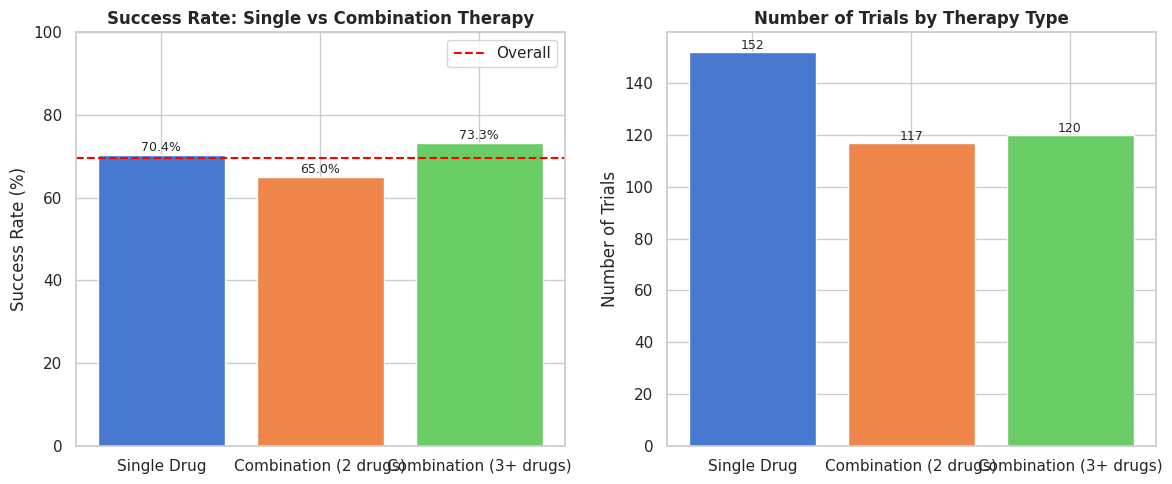


COMBINATION VS SINGLE DRUG SUCCESS RATES
          therapy_type  trials  successes  success_rate_%
 Combination (2 drugs)     117         76            65.0
Combination (3+ drugs)     120         88            73.3
           Single Drug     152        107            70.4


In [30]:
# ─────────────────────────────────────────────────────────
#  COMBINATION VS SINGLE DRUG
# ─────────────────────────────────────────────────────────

df_analysis["interventions_drugs_clean"] = df_analysis[
    "interventions_drugs_clean"
].apply(parse_list_col)

# Count actual drugs only (exclude procedures etc.)
def count_actual_drugs(drug_list):
    NON_DRUG_KEYWORDS = [
        "Placebo", "Radiation", "Surgery", "Imaging",
        "Biospecimen", "Questionnaire", "Tomography",
        "Therapy (unspecified)", "Biopsy", "Procedure"
    ]
    count = 0
    for drug in drug_list:
        if not any(kw.lower() in str(drug).lower() 
                   for kw in NON_DRUG_KEYWORDS):
            count += 1
    return count

df_analysis["drug_count"] = df_analysis[
    "interventions_drugs_clean"
].apply(count_actual_drugs)

df_analysis["therapy_type"] = df_analysis["drug_count"].apply(
    lambda x: "Single Drug" if x == 1 
    else "Combination (2 drugs)" if x == 2
    else "Combination (3+ drugs)" if x >= 3
    else "Unknown"
)

combo_success = df_analysis.groupby(
    "therapy_type"
)["success_binary"].agg(
    trials="count",
    successes="sum"
).reset_index()

combo_success["success_rate_%"] = (
    combo_success["successes"] / combo_success["trials"] * 100
).round(1)

combo_success = combo_success[combo_success["trials"] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Success rate
order = ["Single Drug", "Combination (2 drugs)", "Combination (3+ drugs)"]
combo_plot = combo_success.set_index("therapy_type").reindex(
    [o for o in order if o in combo_success["therapy_type"].values]
).reset_index()

bars = axes[0].bar(
    combo_plot["therapy_type"],
    combo_plot["success_rate_%"],
    color=sns.color_palette("muted")
)
axes[0].set_title("Success Rate: Single vs Combination Therapy",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_ylim(0, 100)
axes[0].axhline(y=df_analysis["success_binary"].mean()*100,
                color="red", linestyle="--", label="Overall")
axes[0].legend()

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontsize=9)

# Trial count
bars2 = axes[1].bar(
    combo_plot["therapy_type"],
    combo_plot["trials"],
    color=sns.color_palette("muted")
)
axes[1].set_title("Number of Trials by Therapy Type",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Number of Trials")

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("combo_vs_single.png", dpi=150)
plt.show()

print("\nCOMBINATION VS SINGLE DRUG SUCCESS RATES")
print("=" * 50)
print(combo_success.to_string(index=False))

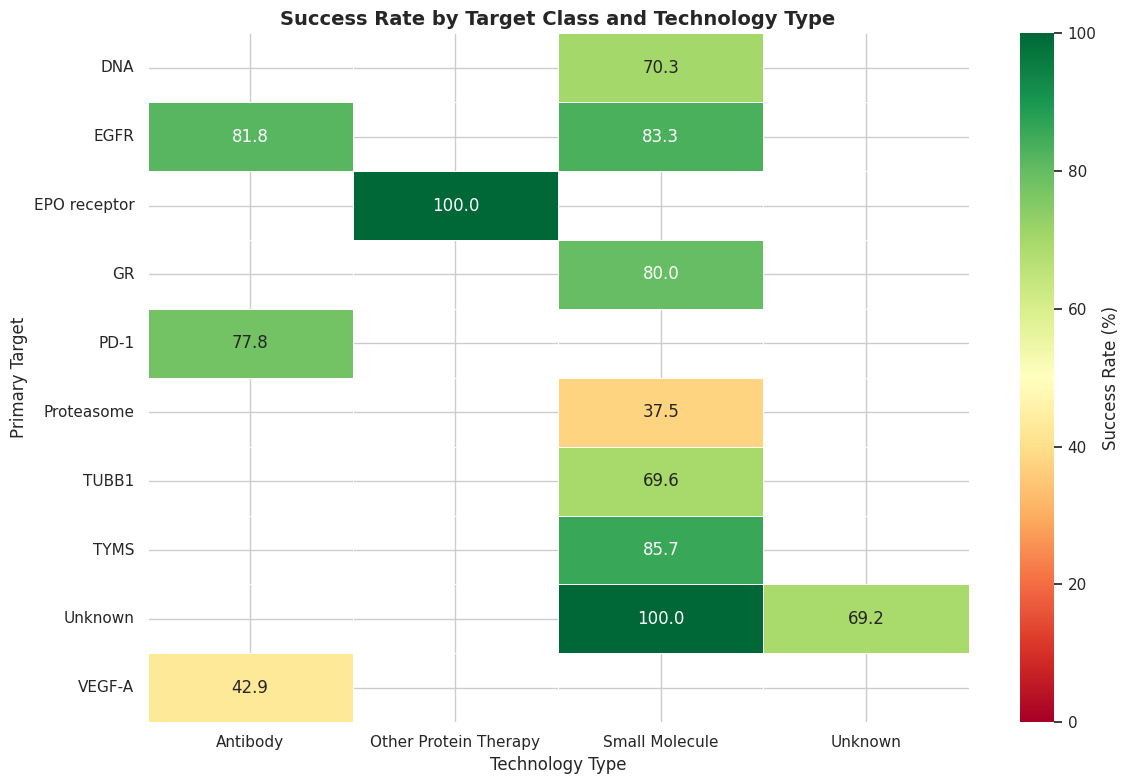


TARGET x TECHNOLOGY SUCCESS RATES
primary_target    primary_technology  trials  successes  success_rate_%
           DNA        Small Molecule      37         26            70.3
          EGFR              Antibody      11          9            81.8
          EGFR        Small Molecule       6          5            83.3
  EPO receptor Other Protein Therapy       5          5           100.0
            GR        Small Molecule      10          8            80.0
          PD-1              Antibody       9          7            77.8
    Proteasome        Small Molecule       8          3            37.5
         TUBB1        Small Molecule      23         16            69.6
          TYMS        Small Molecule      14         12            85.7
       Unknown        Small Molecule       8          8           100.0
       Unknown               Unknown      39         27            69.2
        VEGF-A              Antibody       7          3            42.9


In [31]:
# ─────────────────────────────────────────────────────────
#  TARGET CLASS x TECHNOLOGY HEATMAP
# ─────────────────────────────────────────────────────────

# Focus on meaningful targets and technologies
top_targets = df_analysis["primary_target"].value_counts().head(10).index.tolist()
top_techs   = df_analysis["primary_technology"].value_counts().head(5).index.tolist()

df_cross = df_analysis[
    (df_analysis["primary_target"].isin(top_targets)) &
    (df_analysis["primary_technology"].isin(top_techs))
].copy()

cross_heat = df_cross.groupby(
    ["primary_target", "primary_technology"]
)["success_binary"].agg(
    trials="count",
    successes="sum"
).reset_index()

cross_heat["success_rate_%"] = (
    cross_heat["successes"] / cross_heat["trials"] * 100
).round(1)

# Only keep cells with at least 3 trials
cross_heat = cross_heat[cross_heat["trials"] >= 3]

pivot_heat = cross_heat.pivot(
    index="primary_target",
    columns="primary_technology",
    values="success_rate_%"
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    pivot_heat,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Success Rate (%)"}
)

ax.set_title("Success Rate by Target Class and Technology Type",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Technology Type")
ax.set_ylabel("Primary Target")

plt.tight_layout()
plt.savefig("target_x_technology.png", dpi=150)
plt.show()

print("\nTARGET x TECHNOLOGY SUCCESS RATES")
print("=" * 50)
print(cross_heat.to_string(index=False))